# CliffWalking-v0: SARSA vs Q-Learning (v0)


In [36]:
try:
    import gymnasium as gym
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install gymnasium
    import gymnasium as gym

In [37]:
import gymnasium as gym
from gymnasium.envs.toy_text.cliffwalking import CliffWalkingEnv
from gymnasium.envs.registration import register

register(
    id="CliffWalking-v0",
    entry_point="gymnasium.envs.toy_text.cliffwalking:CliffWalkingEnv",
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment CliffWalking-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Reproducible plotting defaults
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Environment inspection


In [39]:
env = gym.make("CliffWalking-v0")
n_states = env.observation_space.n
n_actions = env.action_space.n
start_state, start_info = env.reset(seed=123)

summary_df = pd.DataFrame({
    "Property": ["Observation space", "Action space", "Number of states", "Number of actions", "Start state"],
    "Value": [str(env.observation_space), str(env.action_space), n_states, n_actions, start_state]
})
summary_df

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CliffWalking-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


,Property,Value
0,Observation space,Discrete(48)
1,Action space,Discrete(4)
2,Number of states,48
3,Number of actions,4
4,Start state,36


## 2. Helper functions



In [40]:
ACTION_NAMES = {0: "Up", 1: "Right", 2: "Down", 3: "Left"}
ACTION_DELTAS = {
    0: (-1, 0),
    1: (0, 1),
    2: (1, 0),
    3: (0, -1),
}

GRID_ROWS = 4
GRID_COLS = 12

def state_to_rc(state, ncols=GRID_COLS):
    return state // ncols, state % ncols

def epsilon_greedy(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(np.random.default_rng(rng.integers(1_000_000_000)).choice(Q.shape[1]))
    return int(np.argmax(Q[state]))

def linear_epsilon_decay(episode_idx, total_episodes, eps_start=0.1, eps_end=0.01):
    frac = episode_idx / max(total_episodes - 1, 1)
    return eps_start + frac * (eps_end - eps_start)

def constant_epsilon(episode_idx, total_episodes, eps=0.1):
    return eps

def moving_average(x, window=20):
    x = np.asarray(x, dtype=float)
    if window <= 1:
        return x.copy()
    if len(x) < window:
        return x.copy()
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

def mean_ci95(arr):
    '''
    arr shape: (n_runs, n_points)
    95% CI computed using NumPy only.
    '''
    arr = np.asarray(arr, dtype=float)
    mean = arr.mean(axis=0)
    std = arr.std(axis=0, ddof=1)
    se = std / np.sqrt(arr.shape[0])
    ci = 1.96 * se
    return mean, ci

## 3. Online SARSA and Q-learning implementations

Both algorithms update immediately after each call to `env.step()`.

### SARSA update
\[
Q(s,a) \leftarrow Q(s,a) + lpha \left[r + \gamma Q(s',a') - Q(s,a)
ight]
\]

### Q-learning update
\[
Q(s,a) \leftarrow Q(s,a) + lpha \left[r + \gamma \max_{a'}Q(s',a') - Q(s,a)
ight]
\]

For terminal transitions, the next-state value is set to **0**.

In [41]:
def train_sarsa(
    seed,
    n_episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon_schedule_fn=constant_epsilon,
    eps_kwargs=None,
):
    if eps_kwargs is None:
        eps_kwargs = {"eps": 0.1}

    rng = np.random.default_rng(seed)
    env = gym.make("CliffWalking-v0")
    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)

    episode_returns = []
    episode_lengths = []
    cliff_falls = []

    for ep in range(n_episodes):
        epsilon = epsilon_schedule_fn(ep, n_episodes, **eps_kwargs)
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        action = epsilon_greedy(Q, state, epsilon, rng)

        done = False
        ep_return = 0.0
        steps = 0
        falls = 0

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if done:
                td_target = reward  # next-state value = 0
                Q[state, action] += alpha * (td_target - Q[state, action])
            else:
                next_epsilon = epsilon_schedule_fn(ep, n_episodes, **eps_kwargs)
                next_action = epsilon_greedy(Q, next_state, next_epsilon, rng)
                td_target = reward + gamma * Q[next_state, next_action]
                Q[state, action] += alpha * (td_target - Q[state, action])
                action = next_action

            # Cliff fall count proxy: large penalty
            if reward <= -100:
                falls += 1

            state = next_state
            ep_return += reward
            steps += 1

        episode_returns.append(ep_return)
        episode_lengths.append(steps)
        cliff_falls.append(falls)

    env.close()
    return {
        "Q": Q,
        "returns": np.array(episode_returns, dtype=float),
        "lengths": np.array(episode_lengths, dtype=float),
        "cliff_falls": np.array(cliff_falls, dtype=float),
    }


def train_q_learning(
    seed,
    n_episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon_schedule_fn=constant_epsilon,
    eps_kwargs=None,
):
    if eps_kwargs is None:
        eps_kwargs = {"eps": 0.1}

    rng = np.random.default_rng(seed)
    env = gym.make("CliffWalking-v0")
    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)

    episode_returns = []
    episode_lengths = []
    cliff_falls = []

    for ep in range(n_episodes):
        epsilon = epsilon_schedule_fn(ep, n_episodes, **eps_kwargs)
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))

        done = False
        ep_return = 0.0
        steps = 0
        falls = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if done:
                td_target = reward  # next-state value = 0
            else:
                td_target = reward + gamma * np.max(Q[next_state])

            Q[state, action] += alpha * (td_target - Q[state, action])

            if reward <= -100:
                falls += 1

            state = next_state
            ep_return += reward
            steps += 1

        episode_returns.append(ep_return)
        episode_lengths.append(steps)
        cliff_falls.append(falls)

    env.close()
    return {
        "Q": Q,
        "returns": np.array(episode_returns, dtype=float),
        "lengths": np.array(episode_lengths, dtype=float),
        "cliff_falls": np.array(cliff_falls, dtype=float),
    }

## 4. Multi-seed experiment runner

We use **30 seeds** by default so the results are not based on one lucky run.

In [42]:
def run_experiment(
    algo_name,
    train_fn,
    seeds=30,
    n_episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon_schedule_fn=constant_epsilon,
    eps_kwargs=None,
):
    all_returns = []
    all_lengths = []
    all_falls = []
    q_tables = []

    for seed in range(seeds):
        out = train_fn(
            seed=seed,
            n_episodes=n_episodes,
            alpha=alpha,
            gamma=gamma,
            epsilon_schedule_fn=epsilon_schedule_fn,
            eps_kwargs=eps_kwargs,
        )
        all_returns.append(out["returns"])
        all_lengths.append(out["lengths"])
        all_falls.append(out["cliff_falls"])
        q_tables.append(out["Q"])

    return {
        "algo": algo_name,
        "returns": np.array(all_returns, dtype=float),
        "lengths": np.array(all_lengths, dtype=float),
        "cliff_falls": np.array(all_falls, dtype=float),
        "Q_tables": q_tables,
    }

## 5. Baseline training: α = 0.5 and constant ε = 0.1


In [43]:
N_SEEDS = 30
N_EPISODES = 500
ALPHA = 0.5
GAMMA = 1.0

sarsa_base = run_experiment(
    algo_name="SARSA",
    train_fn=train_sarsa,
    seeds=N_SEEDS,
    n_episodes=N_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon_schedule_fn=constant_epsilon,
    eps_kwargs={"eps": 0.1},
)

qlearn_base = run_experiment(
    algo_name="Q-learning",
    train_fn=train_q_learning,
    seeds=N_SEEDS,
    n_episodes=N_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon_schedule_fn=constant_epsilon,
    eps_kwargs={"eps": 0.1},
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CliffWalking-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


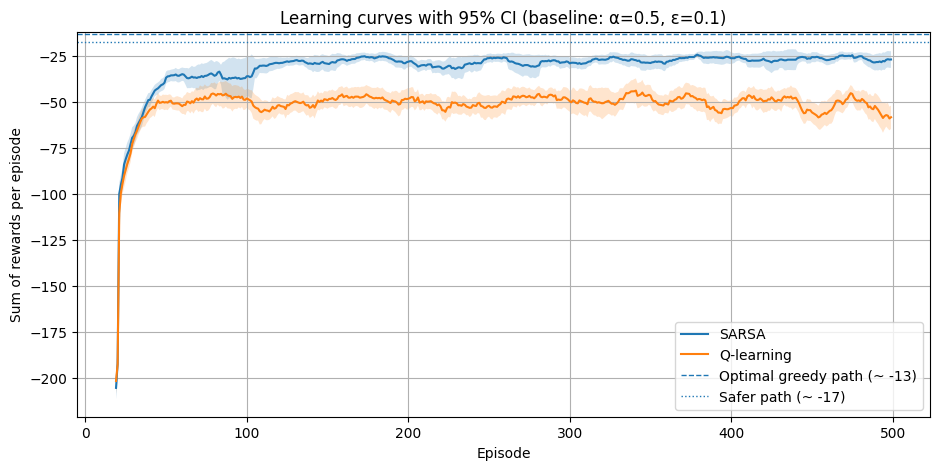

In [44]:
def plot_learning_curves(result_a, result_b, window=20, title_suffix=""):
    arr_a = np.array([moving_average(x, window) for x in result_a["returns"]])
    arr_b = np.array([moving_average(x, window) for x in result_b["returns"]])

    mean_a, ci_a = mean_ci95(arr_a)
    mean_b, ci_b = mean_ci95(arr_b)

    x = np.arange(len(mean_a)) + window - 1

    plt.figure(figsize=(11, 5))
    plt.plot(x, mean_a, label=result_a["algo"])
    plt.fill_between(x, mean_a - ci_a, mean_a + ci_a, alpha=0.2)
    plt.plot(x, mean_b, label=result_b["algo"])
    plt.fill_between(x, mean_b - ci_b, mean_b + ci_b, alpha=0.2)
    plt.axhline(-13, linestyle="--", linewidth=1, label="Optimal greedy path (~ -13)")
    plt.axhline(-17, linestyle=":", linewidth=1, label="Safer path (~ -17)")
    plt.xlabel("Episode")
    plt.ylabel("Sum of rewards per episode")
    plt.title(f"Learning curves with 95% CI {title_suffix}")
    plt.legend()
    plt.show()

plot_learning_curves(sarsa_base, qlearn_base, window=20, title_suffix="(baseline: α=0.5, ε=0.1)")

## 6. Policy arrows, value heatmaps, and sample trajectories
Now we visualize what the agents actually learned.

In [45]:
def plot_policy_arrows(Q, title):
    policy = np.argmax(Q, axis=1)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_xlim(-0.5, GRID_COLS - 0.5)
    ax.set_ylim(GRID_ROWS - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, GRID_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_ROWS, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_title(title)

    # cliff cells: bottom row, columns 1..10
    for c in range(1, 11):
        ax.add_patch(plt.Rectangle((c - 0.5, 3 - 0.5), 1, 1, alpha=0.3))
        ax.text(c, 3, "C", ha="center", va="center", fontsize=10)

    ax.text(0, 3, "S", ha="center", va="center", fontsize=11)
    ax.text(11, 3, "G", ha="center", va="center", fontsize=11)

    for s in range(Q.shape[0]):
        r, c = state_to_rc(s)
        if r == 3 and 1 <= c <= 10:
            continue
        if r == 3 and c == 11:
            continue

        a = policy[s]
        dr, dc = ACTION_DELTAS[a]
        # because plot has inverted y-axis, use x=col, y=row
        ax.arrow(c, r, 0.3 * dc, 0.3 * dr, head_width=0.12, length_includes_head=True)

    plt.show()


def plot_value_heatmap(Q, title):
    V = np.max(Q, axis=1).reshape(GRID_ROWS, GRID_COLS)
    plt.figure(figsize=(12, 4))
    plt.imshow(V, aspect="auto")
    plt.colorbar(label="V(s) = max_a Q(s,a)")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.show()


def rollout_greedy_trajectory(Q, seed=0, max_steps=200):
    env = gym.make("CliffWalking-v0")
    rng = np.random.default_rng(seed)
    state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))

    trajectory = [state]
    rewards = []
    done = False
    steps = 0

    while not done and steps < max_steps:
        action = int(np.argmax(Q[state]))
        next_state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append(next_state)
        rewards.append(reward)
        state = next_state
        done = terminated or truncated
        steps += 1

    env.close()
    return trajectory, rewards


def plot_trajectory(trajectory, title):
    coords = [state_to_rc(s) for s in trajectory]
    rows = [r for r, c in coords]
    cols = [c for r, c in coords]

    plt.figure(figsize=(12, 4))
    plt.xlim(-0.5, GRID_COLS - 0.5)
    plt.ylim(GRID_ROWS - 0.5, -0.5)
    plt.xticks(range(GRID_COLS))
    plt.yticks(range(GRID_ROWS))
    plt.grid(True)

    for c in range(1, 11):
        plt.gca().add_patch(plt.Rectangle((c - 0.5, 3 - 0.5), 1, 1, alpha=0.3))
        plt.text(c, 3, "C", ha="center", va="center")

    plt.text(0, 3, "S", ha="center", va="center")
    plt.text(11, 3, "G", ha="center", va="center")

    plt.plot(cols, rows, marker="o")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.show()

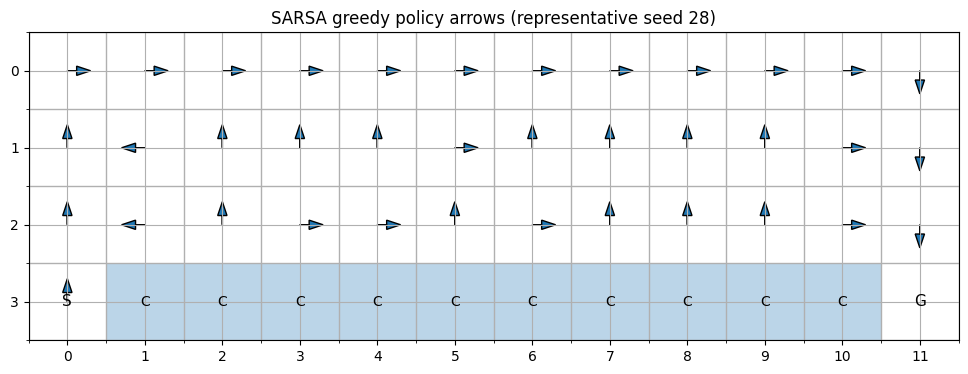

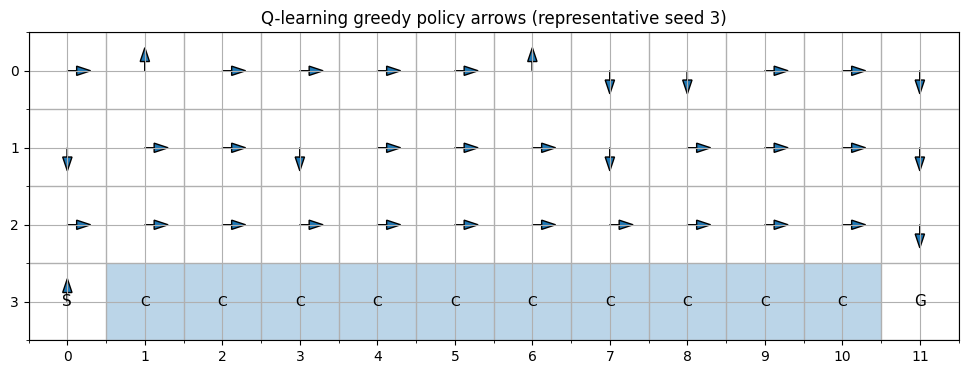

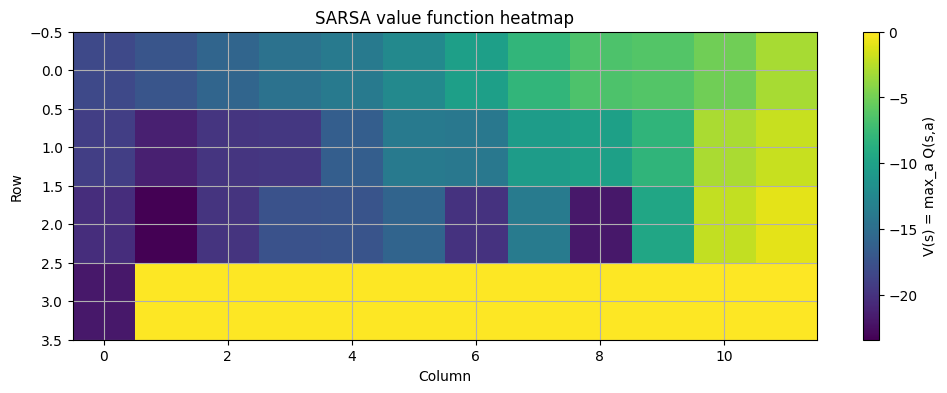

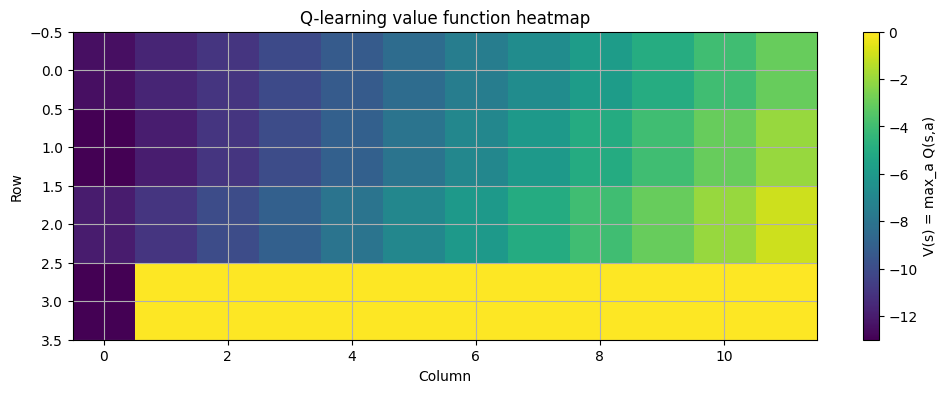

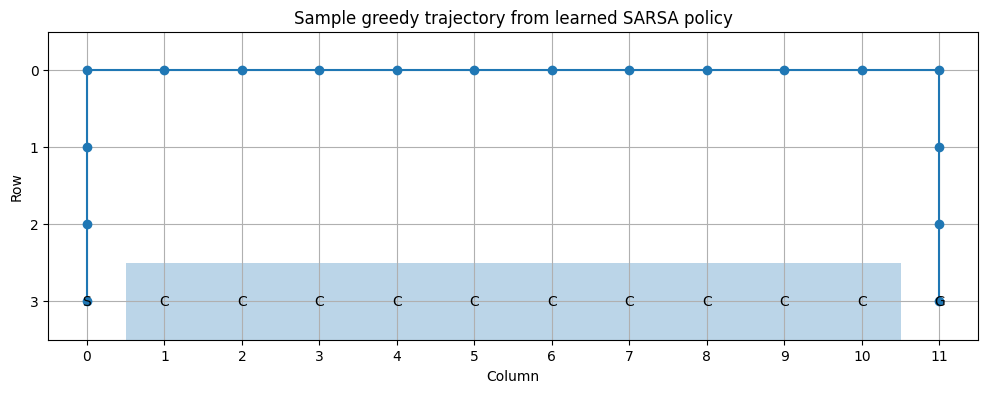

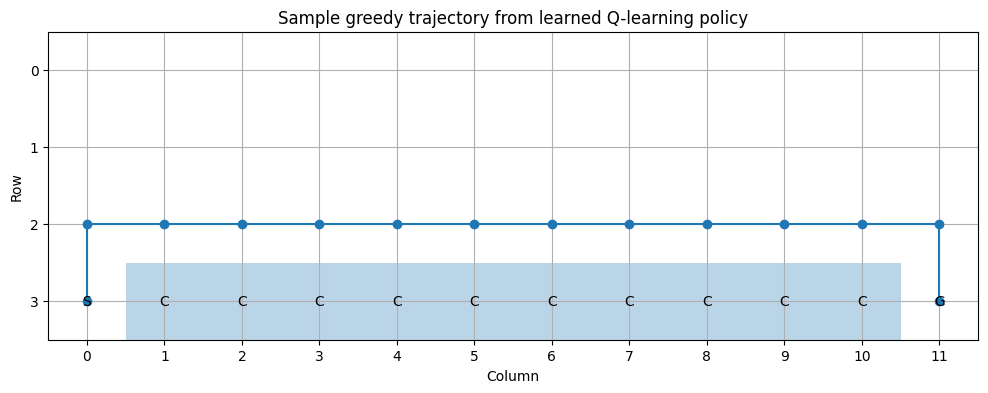

In [46]:
# Use representative Q-table: median seed by final 50-episode performance
def representative_q(result):
    final_scores = result["returns"][:, -50:].mean(axis=1)
    median_idx = np.argsort(final_scores)[len(final_scores) // 2]
    return result["Q_tables"][median_idx], median_idx, final_scores[median_idx]

Q_sarsa_rep, idx_sarsa, sarsa_score = representative_q(sarsa_base)
Q_q_rep, idx_q, q_score = representative_q(qlearn_base)

plot_policy_arrows(Q_sarsa_rep, f"SARSA greedy policy arrows (representative seed {idx_sarsa})")
plot_policy_arrows(Q_q_rep, f"Q-learning greedy policy arrows (representative seed {idx_q})")

plot_value_heatmap(Q_sarsa_rep, "SARSA value function heatmap")
plot_value_heatmap(Q_q_rep, "Q-learning value function heatmap")

traj_sarsa, rew_sarsa = rollout_greedy_trajectory(Q_sarsa_rep, seed=123)
traj_q, rew_q = rollout_greedy_trajectory(Q_q_rep, seed=123)

plot_trajectory(traj_sarsa, "Sample greedy trajectory from learned SARSA policy")
plot_trajectory(traj_q, "Sample greedy trajectory from learned Q-learning policy")

## 7. Experiment 1: step-size α comparison
We compare several learning rates while keeping the exploration rule fixed.

In [47]:
alpha_values = [0.1, 0.3, 0.5]

alpha_rows = []

for alpha in alpha_values:
    sarsa_res = run_experiment(
        algo_name="SARSA",
        train_fn=train_sarsa,
        seeds=N_SEEDS,
        n_episodes=N_EPISODES,
        alpha=alpha,
        gamma=GAMMA,
        epsilon_schedule_fn=constant_epsilon,
        eps_kwargs={"eps": 0.1},
    )
    q_res = run_experiment(
        algo_name="Q-learning",
        train_fn=train_q_learning,
        seeds=N_SEEDS,
        n_episodes=N_EPISODES,
        alpha=alpha,
        gamma=GAMMA,
        epsilon_schedule_fn=constant_epsilon,
        eps_kwargs={"eps": 0.1},
    )

    for res in [sarsa_res, q_res]:
        mean_final = res["returns"][:, -50:].mean(axis=1).mean()
        mean_overall = res["returns"].mean()
        mean_falls = res["cliff_falls"].mean()
        alpha_rows.append([res["algo"], alpha, mean_final, mean_overall, mean_falls])

alpha_df = pd.DataFrame(alpha_rows, columns=["Algorithm", "alpha", "Final-50 avg return", "Overall avg return", "Avg cliff falls per episode"])
alpha_df.sort_values(["Algorithm", "alpha"])

,Algorithm,alpha,Final-50 avg return,Overall avg return,Avg cliff falls per episode
1,Q-learning,0.1,-51.666000,-71.059267,0.379533
3,Q-learning,0.3,-52.290667,-58.637000,0.361733
5,Q-learning,0.5,-53.430000,-56.238200,0.360000
0,SARSA,0.1,-22.146000,-51.859067,0.171067
2,SARSA,0.3,-23.611333,-36.093733,0.103200
4,SARSA,0.5,-26.004000,-36.347333,0.101133


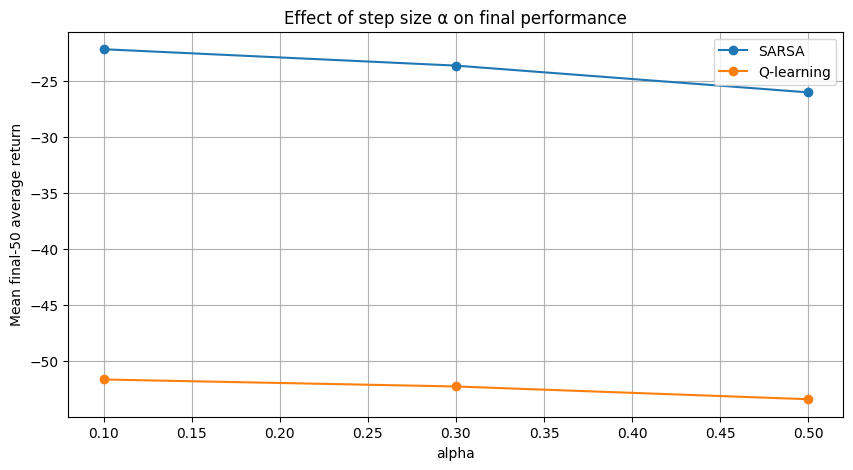

In [48]:
plt.figure(figsize=(10, 5))
for algo in ["SARSA", "Q-learning"]:
    sub = alpha_df[alpha_df["Algorithm"] == algo]
    plt.plot(sub["alpha"], sub["Final-50 avg return"], marker="o", label=algo)
plt.xlabel("alpha")
plt.ylabel("Mean final-50 average return")
plt.title("Effect of step size α on final performance")
plt.legend()
plt.show()

## 8. Experiment 2: ε schedule comparison
We compare:
- **constant ε = 0.1**
- **linear decay from 0.1 to 0.01**

In [49]:
schedule_rows = []

schedule_configs = [
    ("constant", constant_epsilon, {"eps": 0.1}),
    ("linear_decay", linear_epsilon_decay, {"eps_start": 0.1, "eps_end": 0.01}),
]

schedule_results = {}

for sched_name, sched_fn, sched_kwargs in schedule_configs:
    sarsa_res = run_experiment(
        algo_name="SARSA",
        train_fn=train_sarsa,
        seeds=N_SEEDS,
        n_episodes=N_EPISODES,
        alpha=0.5,
        gamma=GAMMA,
        epsilon_schedule_fn=sched_fn,
        eps_kwargs=sched_kwargs,
    )
    q_res = run_experiment(
        algo_name="Q-learning",
        train_fn=train_q_learning,
        seeds=N_SEEDS,
        n_episodes=N_EPISODES,
        alpha=0.5,
        gamma=GAMMA,
        epsilon_schedule_fn=sched_fn,
        eps_kwargs=sched_kwargs,
    )
    schedule_results[("SARSA", sched_name)] = sarsa_res
    schedule_results[("Q-learning", sched_name)] = q_res

    for res in [sarsa_res, q_res]:
        schedule_rows.append([
            res["algo"],
            sched_name,
            res["returns"][:, -50:].mean(axis=1).mean(),
            res["returns"].mean(),
            res["cliff_falls"].mean()
        ])

schedule_df = pd.DataFrame(schedule_rows, columns=["Algorithm", "Schedule", "Final-50 avg return", "Overall avg return", "Avg cliff falls per episode"])
schedule_df.sort_values(["Algorithm", "Schedule"])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CliffWalking-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


,Algorithm,Schedule,Final-50 avg return,Overall avg return,Avg cliff falls per episode
1,Q-learning,constant,-53.430000,-56.238200,0.360000
3,Q-learning,linear_decay,-17.470667,-38.475333,0.199733
0,SARSA,constant,-26.004000,-36.347333,0.101133
2,SARSA,linear_decay,-18.886000,-31.223133,0.075467


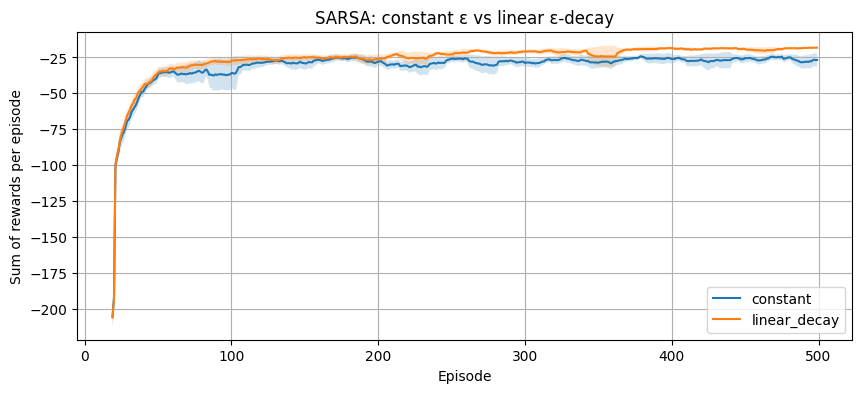

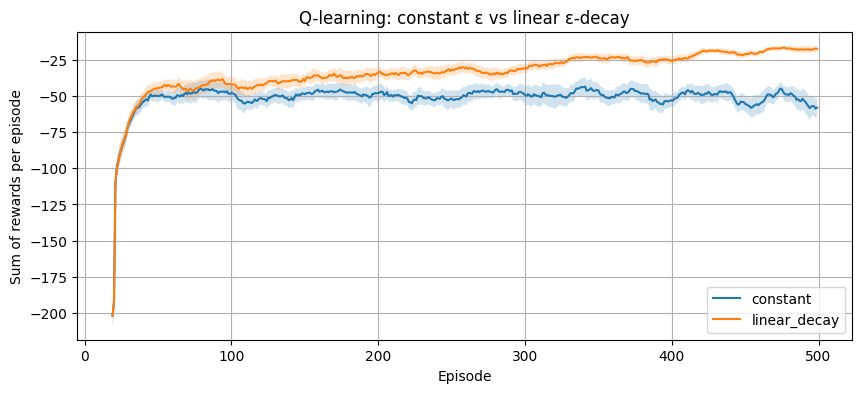

In [50]:
for algo in ["SARSA", "Q-learning"]:
    plt.figure(figsize=(10, 4))
    for sched_name in ["constant", "linear_decay"]:
        res = schedule_results[(algo, sched_name)]
        arr = np.array([moving_average(x, 20) for x in res["returns"]])
        mean, ci = mean_ci95(arr)
        x = np.arange(len(mean)) + 19
        plt.plot(x, mean, label=sched_name)
        plt.fill_between(x, mean - ci, mean + ci, alpha=0.2)
    plt.title(f"{algo}: constant ε vs linear ε-decay")
    plt.xlabel("Episode")
    plt.ylabel("Sum of rewards per episode")
    plt.legend()
    plt.show()

## 9. Comparison table: final performance, learning speed, and sample efficiency



In [51]:
def learning_speed_episode(returns_2d, window=20):
    arr = np.array([moving_average(x, window) for x in returns_2d])
    mean_curve = arr.mean(axis=0)
    final_level = mean_curve[-50:].mean()
    threshold = final_level - 0.10 * abs(final_level)  # 90% of final level in a reward sense
    idx = np.where(mean_curve >= threshold)[0]
    if len(idx) == 0:
        return np.nan
    return int(idx[0] + window - 1)

comparison_rows = []

comparison_inputs = [
    ("SARSA", sarsa_base),
    ("Q-learning", qlearn_base),
    ("SARSA + ε-decay", schedule_results[("SARSA", "linear_decay")]),
    ("Q-learning + ε-decay", schedule_results[("Q-learning", "linear_decay")]),
]

for label, res in comparison_inputs:
    final_perf = res["returns"][:, -50:].mean(axis=1)
    sample_eff = res["returns"][:, :100].mean(axis=1)
    learn_speed = learning_speed_episode(res["returns"], window=20)
    cliff_rate = res["cliff_falls"].mean()

    comparison_rows.append([
        label,
        final_perf.mean(),
        sample_eff.mean(),
        learn_speed,
        cliff_rate
    ])

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Setting", "Final performance", "Sample efficiency (first 100 eps)", "Learning speed episode", "Avg cliff falls per episode"]
)

comparison_df.sort_values("Final performance", ascending=False)

,Setting,Final performance,Sample efficiency (first 100 eps),Learning speed episode,Avg cliff falls per episode
3,Q-learning + ε-decay,-17.470667,-76.613333,419,0.199733
2,SARSA + ε-decay,-18.886000,-68.664000,263,0.075467
0,SARSA,-26.004000,-72.250000,117,0.101133
1,Q-learning,-53.430000,-80.473333,37,0.360000
